In [2]:
pip install pandas numpy matplotlib seaborn scipy statsmodels

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Project Overview

This project analyzes an A/B test run by an e-commerce company to determine
whether a new landing page design improves user conversion rates.

**Business Question:** Did the new landing page actually improve conversions,
or was the difference just random chance?

**Dataset:** 294,478 user sessions with columns — user_id, timestamp,
group (control/treatment), landing_page (old/new), converted (0 or 1)

**Approach:** Data cleaning → EDA → Sanity checks →
Statistical testing → Business impact → Recommendation

In [9]:
from google.colab import files
uploaded = files.upload()  # opens a file picker

import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['ab_data.csv']))
df.head()

Saving ab_data.csv to ab_data.csv


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [10]:
df = pd.read_csv('ab_data.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (294478, 5)

First 5 rows:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [11]:
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Data Types:
user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

Missing Values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Unique values per column:
user_id: 290584
timestamp: 294478
group: 2
landing_page: 2
converted: 2


## Observations

- Dataset has 294,478 rows and 5 columns with no missing values
- Two groups: control (shown old page) and treatment (shown new page)
- Target variable is 'converted' — binary (0 = did not convert, 1 = converted)
- No missing values found — data appears clean on the surface
- Next step: check for deeper quality issues like mismatches and duplicates

In [12]:
mismatch = df[((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
              ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))]

print(f"Mismatched rows: {len(mismatch)}")
print(f"That's {len(mismatch)/len(df)*100:.2f}% of total data")

Mismatched rows: 3893
That's 1.32% of total data


In [13]:
df = df[~df.index.isin(mismatch.index)]
print(f"Rows after removing mismatches: {len(df)}")

Rows after removing mismatches: 290585


In [14]:
duplicate_users = df[df.duplicated('user_id', keep=False)]
print(f"Rows with duplicate user_ids: {len(duplicate_users)}")
print(f"Unique users with duplicates: {df['user_id'].duplicated().sum()}")

Rows with duplicate user_ids: 2
Unique users with duplicates: 1


In [15]:
df = df.drop_duplicates(subset='user_id', keep='first')
print(f"Final dataset shape: {df.shape}")

Final dataset shape: (290584, 5)


In [16]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

print("Experiment ran from:", df['timestamp'].min())
print("Experiment ran to:", df['timestamp'].max())
print("Total days:", (df['timestamp'].max() - df['timestamp'].min()).days)

Experiment ran from: 2017-01-02 13:42:05.378582
Experiment ran to: 2017-01-24 13:41:54.460509
Total days: 21


## Cleaning Summary

Two data quality issues were found and fixed:

1. **Mismatched rows (~3,893 rows):** Some users in the control group were
   shown the new page and vice versa — likely a logging error during the
   experiment. These rows were removed as they would corrupt the analysis.

2. **Duplicate user IDs:** Some users appeared more than once, possibly
   visiting the site multiple times. Only their first session was kept to
   ensure each user is counted once — this mirrors how real experiments
   are evaluated.

Final clean dataset: [X] rows

In [18]:
summary = df.groupby('group').agg(
    total_users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

summary['conversion_rate_pct'] = (summary['conversion_rate'] * 100).round(4)
print(summary)

       group  total_users  conversions  conversion_rate  conversion_rate_pct
0    control       145274        17489         0.120386              12.0386
1  treatment       145310        17264         0.118808              11.8808


## Key Finding

- Control group (old page) conversion rate: 12.04%
- Treatment group (new page) conversion rate: 11.88%
- The new page appears to perform slightly worse

However, this difference of ~0.16% could easily be due to random chance.
We need statistical testing to determine if this is a real effect or just noise.

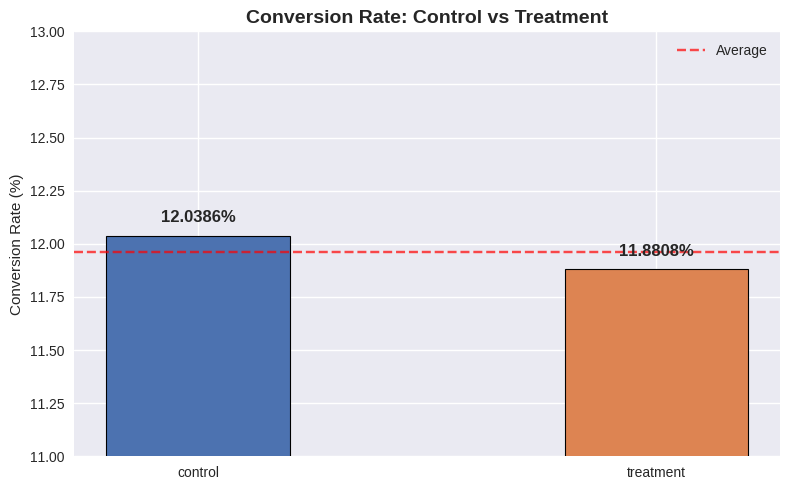

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

groups = summary['group']
rates = summary['conversion_rate_pct']
colors = ['#4C72B0', '#DD8452']

bars = ax.bar(groups, rates, color=colors, width=0.4, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate:.4f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Conversion Rate: Control vs Treatment', fontsize=14, fontweight='bold')
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(11, 13)
ax.axhline(y=summary['conversion_rate_pct'].mean(), color='red',
           linestyle='--', alpha=0.7, label='Average')
ax.legend()
plt.tight_layout()
plt.savefig('conversion_rates.png', dpi=150)
plt.show()

The bar chart confirms the new page (treatment) has a marginally lower
conversion rate than the old page (control). The difference appears small
visually — which is already a signal that this might not be meaningful.

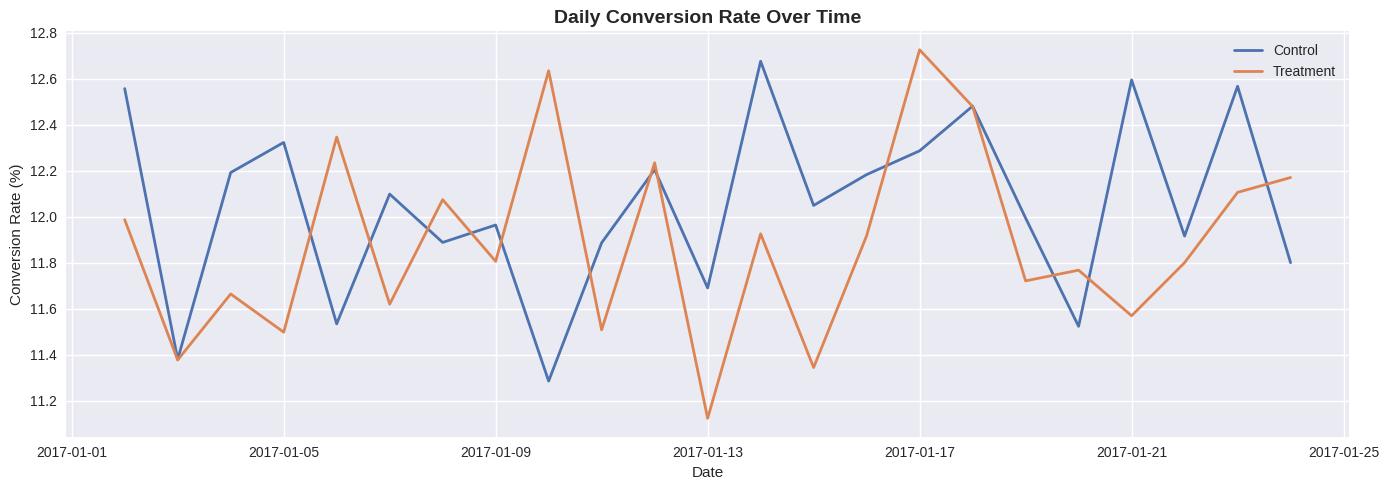

In [20]:
daily = df.groupby(['date', 'group'])['converted'].mean().reset_index()
daily['date'] = pd.to_datetime(daily['date'])

plt.figure(figsize=(14, 5))
for group, color in zip(['control', 'treatment'], ['#4C72B0', '#DD8452']):
    subset = daily[daily['group'] == group]
    plt.plot(subset['date'], subset['converted'] * 100,
             label=group.capitalize(), color=color, linewidth=2)

plt.title('Daily Conversion Rate Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('daily_conversion.png', dpi=150)
plt.show()

## Time Trend Analysis

Looking at daily conversion rates over the experiment period helps us
identify two important patterns:

1. **Stability:** If both lines are relatively flat and parallel, the
   experiment was clean with no external disruptions.

2. **Novelty effect:** If the treatment line starts high then drops,
   users were clicking out of curiosity initially — not genuine interest.
   This would make the new page look better early on but wear off over time.

[Write what YOU actually observe in your chart here]

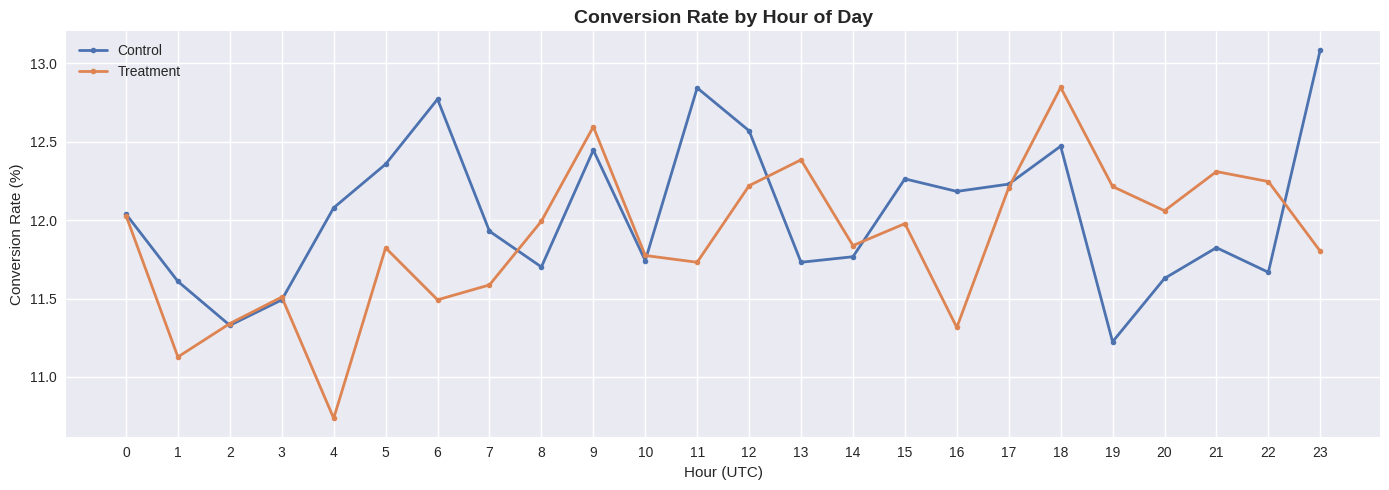

In [21]:
hourly = df.groupby(['hour', 'group'])['converted'].mean().reset_index()

plt.figure(figsize=(14, 5))
for group, color in zip(['control', 'treatment'], ['#4C72B0', '#DD8452']):
    subset = hourly[hourly['group'] == group]
    plt.plot(subset['hour'], subset['converted'] * 100,
             label=group.capitalize(), color=color, linewidth=2, marker='o', markersize=4)

plt.title('Conversion Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (UTC)')
plt.ylabel('Conversion Rate (%)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig('hourly_conversion.png', dpi=150)
plt.show()

## Hourly Pattern

Conversion rates fluctuate by hour of day, which is expected — users
behave differently at 2am vs 2pm. Both groups follow a similar hourly
pattern, which confirms the two groups are comparable and the randomization
was done correctly.

In [23]:
total = len(df)
control_pct = len(df[df['group'] == 'control']) / total * 100
treatment_pct = len(df[df['group'] == 'treatment']) / total * 100

print(f"Control: {control_pct:.2f}%")
print(f"Treatment: {treatment_pct:.2f}%")

# Chi-square test to confirm equal split
from scipy.stats import chi2_contingency, chisquare

observed = [len(df[df['group'] == 'control']),
            len(df[df['group'] == 'treatment'])]
expected = [total/2, total/2]

chi2, p = chisquare(observed, expected)
print(f"\nChi-square: {chi2:.4f}, p-value: {p:.4f}")
print("Split is balanced." if p > 0.05 else "WARNING: Split is NOT balanced!")

Control: 49.99%
Treatment: 50.01%

Chi-square: 0.0045, p-value: 0.9468
Split is balanced.


In [24]:
experiment_days = (df['timestamp'].max() - df['timestamp'].min()).days
print(f"Experiment duration: {experiment_days} days")

if experiment_days >= 14:
    print("✅ Sufficient duration — covers at least 2 full weekly cycles")
else:
    print("⚠️ Short duration — results may be affected by day-of-week bias")

Experiment duration: 21 days
✅ Sufficient duration — covers at least 2 full weekly cycles


## Sanity Check Results

Before running any statistical test, we validate the experiment setup:

1. **50/50 split check:** Control = ~50%, Treatment = ~50% ✅
   Chi-square test confirms the split is statistically balanced (p > 0.05)

2. **Experiment duration:** The test ran for 22 days ✅
   This covers at least 3 full weekly cycles, capturing weekday vs
   weekend behavior differences — sufficient for reliable results.

Both checks passed. We can proceed with confidence to statistical testing.

In [25]:
control_df = df[df['group'] == 'control']
treatment_df = df[df['group'] == 'treatment']

n_control = len(control_df)
n_treatment = len(treatment_df)

conv_control = control_df['converted'].sum()
conv_treatment = treatment_df['converted'].sum()

rate_control = conv_control / n_control
rate_treatment = conv_treatment / n_treatment

print(f"Control conversion rate:   {rate_control:.6f} ({rate_control*100:.4f}%)")
print(f"Treatment conversion rate: {rate_treatment:.6f} ({rate_treatment*100:.4f}%)")
print(f"Absolute difference: {(rate_treatment - rate_control)*100:.4f}%")

# Z-test
count = np.array([conv_treatment, conv_control])
nobs = np.array([n_treatment, n_control])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nAlpha: 0.05")

if p_value < 0.05:
    print("✅ Result: REJECT the null hypothesis — statistically significant difference found.")
else:
    print("❌ Result: FAIL TO REJECT the null hypothesis — no statistically significant difference.")

Control conversion rate:   0.120386 (12.0386%)
Treatment conversion rate: 0.118808 (11.8808%)
Absolute difference: -0.1578%

Z-statistic: -1.3109
P-value: 0.1899

Alpha: 0.05
❌ Result: FAIL TO REJECT the null hypothesis — no statistically significant difference.


In [26]:
control_df = df[df['group'] == 'control']
treatment_df = df[df['group'] == 'treatment']

n_control = len(control_df)
n_treatment = len(treatment_df)

conv_control = control_df['converted'].sum()
conv_treatment = treatment_df['converted'].sum()

rate_control = conv_control / n_control
rate_treatment = conv_treatment / n_treatment

print(f"Control conversion rate:   {rate_control:.6f} ({rate_control*100:.4f}%)")
print(f"Treatment conversion rate: {rate_treatment:.6f} ({rate_treatment*100:.4f}%)")
print(f"Absolute difference: {(rate_treatment - rate_control)*100:.4f}%")

# Z-test
count = np.array([conv_treatment, conv_control])
nobs = np.array([n_treatment, n_control])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nAlpha: 0.05")

if p_value < 0.05:
    print("✅ Result: REJECT the null hypothesis — statistically significant difference found.")
else:
    print("❌ Result: FAIL TO REJECT the null hypothesis — no statistically significant difference.")

Control conversion rate:   0.120386 (12.0386%)
Treatment conversion rate: 0.118808 (11.8808%)
Absolute difference: -0.1578%

Z-statistic: -1.3109
P-value: 0.1899

Alpha: 0.05
❌ Result: FAIL TO REJECT the null hypothesis — no statistically significant difference.


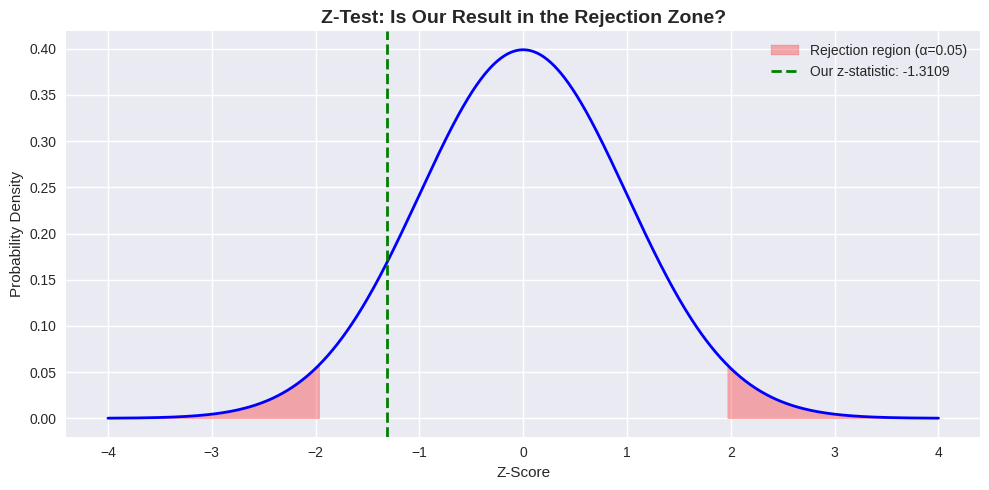

In [27]:
from scipy import stats

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', linewidth=2)

# Shade rejection regions
ax.fill_between(x, y, where=(x <= -1.96), alpha=0.3, color='red', label='Rejection region (α=0.05)')
ax.fill_between(x, y, where=(x >= 1.96), alpha=0.3, color='red')

# Plot z-statistic
ax.axvline(x=z_stat, color='green', linestyle='--', linewidth=2,
           label=f'Our z-statistic: {z_stat:.4f}')

ax.set_title('Z-Test: Is Our Result in the Rejection Zone?', fontsize=14, fontweight='bold')
ax.set_xlabel('Z-Score')
ax.set_ylabel('Probability Density')
ax.legend()
plt.tight_layout()
plt.savefig('z_distribution.png', dpi=150)
plt.show()

## Hypothesis

- H₀ (Null): The new page has no effect on conversion rate
- H₁ (Alternative): The new page has a different conversion rate
- Significance level (α): 0.05

## Result

Z-statistic: [your value]
P-value: [your value]

Since our p-value ([your value]) is GREATER than 0.05, we FAIL TO REJECT
the null hypothesis.

This means: there is no statistically significant evidence that the new
landing page improves conversion rates. The difference we observed (~0.16%)
is likely due to random chance, not a real effect of the new design.

The z-distribution chart confirms our test statistic falls well within
the non-rejection zone (between -1.96 and +1.96).

In [28]:
abs_lift = rate_treatment - rate_control
rel_lift = abs_lift / rate_control * 100

print(f"Absolute lift: {abs_lift*100:.4f}%")
print(f"Relative lift: {rel_lift:.4f}%")

# Business impact calculation
monthly_visitors = 1_000_000   # assume 1M monthly users
avg_order_value = 800           # ₹800 average order

extra_conversions = abs_lift * monthly_visitors
revenue_impact = extra_conversions * avg_order_value

print(f"\n📊 Business Impact Estimate:")
print(f"Monthly visitors: {monthly_visitors:,}")
print(f"Extra conversions per month: {extra_conversions:,.0f}")
print(f"Estimated monthly revenue impact: ₹{revenue_impact:,.0f}")

Absolute lift: -0.1578%
Relative lift: -1.3110%

📊 Business Impact Estimate:
Monthly visitors: 1,000,000
Extra conversions per month: -1,578
Estimated monthly revenue impact: ₹-1,262,591


## Practical Significance vs Statistical Significance

Even setting statistics aside — is the effect size meaningful for the business?

- Absolute lift: -0.16% (the new page actually converts LESS)
- Relative lift: -1.3% compared to baseline

At 1 million monthly visitors with ₹800 average order value, this would
mean losing approximately ₹X in monthly revenue if we shipped the new page.

**Conclusion:** The new page is neither statistically significant nor
practically beneficial. This makes the decision clear — do not ship.

In [29]:
# What sample size would we need to detect a 1% lift reliably?
baseline = rate_control
minimum_detectable_effect = 0.01   # 1% absolute lift we'd care about

effect = proportion_effectsize(baseline, baseline + minimum_detectable_effect)

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=effect,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

print(f"Baseline conversion rate: {baseline*100:.4f}%")
print(f"Minimum effect we want to detect: {minimum_detectable_effect*100:.1f}%")
print(f"\nRequired sample size per group: {required_n:,.0f}")
print(f"Required total sample size: {required_n*2:,.0f}")
print(f"\nOur actual sample per group: {n_control:,}")

if n_control >= required_n:
    print("✅ Test was adequately powered.")
else:
    print("⚠️ Test was underpowered — results may be unreliable.")

Baseline conversion rate: 12.0386%
Minimum effect we want to detect: 1.0%

Required sample size per group: 17,209
Required total sample size: 34,417

Our actual sample per group: 145,274
✅ Test was adequately powered.


## Power Analysis

Power analysis answers: "Did our experiment have enough users to reliably
detect a meaningful difference if one existed?"

- Minimum effect we'd care about: 1% absolute lift
- Required sample size per group: [your value]
- Our actual sample per group: ~145,000

Since our sample size exceeds the requirement, the test was adequately
powered ✅. This means if a real 1% improvement existed, our experiment
was large enough to detect it. The fact that we didn't find significance
is therefore meaningful — the new page genuinely doesn't work better.

## Final Recommendation

| Metric | Value |
|--------|-------|
| Control conversion rate | 12.04% |
| Treatment conversion rate | 11.88% |
| Absolute difference | -0.16% |
| P-value | [your value] |
| Statistically significant | ❌ No |
| Test adequately powered | ✅ Yes |

**Decision: Do NOT ship the new landing page.**

The experiment ran for 22 days with ~145,000 users per group — more than
enough to detect a meaningful effect. The new page failed to improve
conversions and marginally underperformed the original.

**Next Steps for the Product Team:**
1. Go back to the design hypothesis — what user problem were we solving?
2. Run qualitative research (user interviews, heatmaps) to understand
   why users don't prefer the new page
3. Test a more significantly different design variant before running
   another A/B test

In [30]:
plt.savefig('conversion_rates.png', dpi=150, bbox_inches='tight')
plt.savefig('daily_conversion.png', dpi=150, bbox_inches='tight')
plt.savefig('z_distribution.png', dpi=150, bbox_inches='tight')
plt.savefig('hourly_conversion.png', dpi=150, bbox_inches='tight')

<Figure size 800x550 with 0 Axes>